<a href="https://colab.research.google.com/github/vadimrusmoto-dotcom/coffee-prices-analysis/blob/main/analisys_coffee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка
df = pd.read_csv('coffee_prices_rf.csv', sep=';', decimal=',')

# Преобразуем цену в число (исправление)
df['avg_price'] = df['avg_price'].astype(float)

# Проверяем
print(df['avg_price'].dtype)  # Теперь должно быть float64


float64


In [48]:
print('Первые 5 строк:')
print(df.head())
print('\n Информация о данных:')
print (df.info())
print('\n Статистика по ценам' )
print(df['avg_price'].describe())

Первые 5 строк:
         date  avg_price
0  01.01.2024    1467.84
1  01.02.2024    1465.29
2  01.03.2024    1462.04
3  01.04.2024    1475.71
4  01.05.2024    1485.48

 Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       30 non-null     object 
 1   avg_price  30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
None

 Статистика по ценам
count      30.000000
mean     1777.388000
std       256.721649
min      1462.040000
25%      1507.472500
50%      1773.540000
75%      2043.072500
max      2116.100000
Name: avg_price, dtype: float64


In [49]:
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')

# Проверим
print("Тип данных после преобразования:")
print(df['date'].head())
print(df.info())


Тип данных после преобразования:
0   2024-01-01
1   2024-02-01
2   2024-03-01
3   2024-04-01
4   2024-05-01
Name: date, dtype: datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       30 non-null     datetime64[ns]
 1   avg_price  30 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 612.0 bytes
None


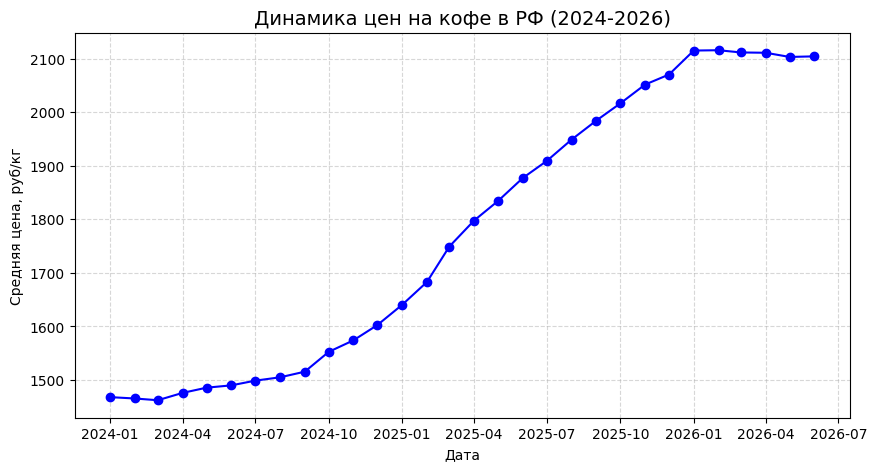

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['avg_price'], marker='o', linestyle='-', color='blue')
plt.title('Динамика цен на кофе в РФ (2024-2026)', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Средняя цена, руб/кг')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('line_plot.png', dpi=150)
plt.show()

In [51]:
df['year'] = df['date'].dt.year
annual_avg = df.groupby('year')['avg_price'].mean()
print(annual_avg)

year
2024    1507.8375
2025    1880.3775
2026    2110.5100
Name: avg_price, dtype: float64


In [52]:
# 4.1 Группируем по году
df['year'] = df['date'].dt.year
annual_avg = df.groupby('year')['avg_price'].mean()
print("Средняя цена по годам:")
print(annual_avg)


Средняя цена по годам:
year
2024    1507.8375
2025    1880.3775
2026    2110.5100
Name: avg_price, dtype: float64


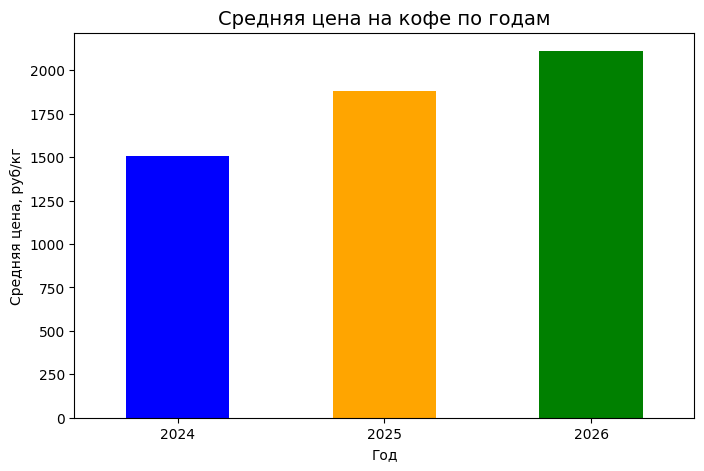

In [53]:
# 4.2 Столбчатая диаграмма
plt.figure(figsize=(8, 5))
annual_avg.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title('Средняя цена на кофе по годам', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Средняя цена, руб/кг')
plt.xticks(rotation=0)
plt.savefig('bar_plot.png', dpi=150)
plt.show()

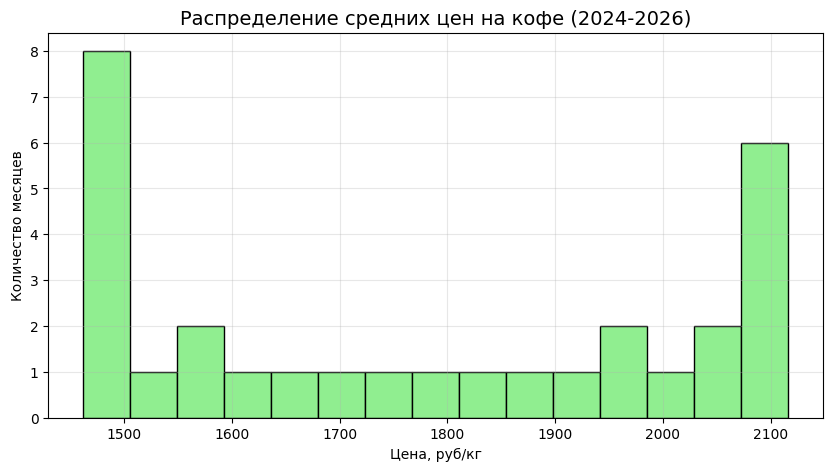

In [56]:
# 5.1 Гистограмма распределения цен
plt.figure(figsize=(10, 5))
plt.hist(df['avg_price'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Распределение средних цен на кофе (2024-2026)', fontsize=14)
plt.xlabel('Цена, руб/кг')
plt.ylabel('Количество месяцев')
plt.grid(True, alpha=0.3)
plt.savefig('hist_plot.png', dpi=150)
plt.show()